# Models Experiments

The Brazil dataset has unbalanced class distribution where the percentage of death class samples is outnumbered by the percentage of living class samples, being 99.4\% of the living class, and just 0.6\% of the dead class. This problem is often referred to in the literature as the “class imbalance” problem and can generate low performance classifiers, especially when predicting low (minority) represented classes. Because of the unbalanced nature of this data, we choose to train the models on a construct balanced data with same proportion of alive and death sample.

### CONTENTS

* [Imports](#Imports)  
* [Load Datasets](#load)
* [Minor Data Preprocessing](#minor)
* [Split the data into balanced and unbalanced data](#split_balanc)
* [Generate One-Hot Enconded Dataset](#OHE)
* [Train and Test dataset - Balanced data](#split)
* [Models](#models)
* [Generate Metrics: ROC Curve and Confusion Matrix](#metrics)


<a id='Imports'></a>
### Imports

In [153]:
import pandas as pd
from sklearn.model_selection import train_test_split
import pandas as pd
import os
import zipfile
import os,glob
import numpy as np
pd.options.display.max_columns = None
pd.options.display.max_rows = 1000
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support, roc_auc_score, accuracy_score
from sklearn import metrics
import numpy as np
import os

from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from xgboost import XGBClassifier
from xgboost import plot_tree
from sklearn.cluster import KMeans
from statistics import mean
import joblib

<a id='load'></a>
### Load datasets

The dataset use here is the one generates in the notebook Data_Cleaning_Preprocessing_Brazil with the variables created on the Synthetic_Categorical_Features_Creation notebook.

In [2]:
%cd /home/narruda/Merge_Neonatal/Merge_sample_90/Dataset_models/Dataset_without_ignored/By_UF

/home/narruda/Merge_Neonatal/Merge_sample_90/Dataset_models/Dataset_without_ignored/By_UF


In [5]:
df_total = {}
for filename in glob.glob('*.csv'):
    df_total[filename[:-4]] = pd.read_csv(filename, sep=",", encoding = "latin-1",low_memory=False)   

In [6]:
df_brasil_sample_90_without_na_and_ignored = pd.DataFrame()
for key, values in df_total.items():
    df_brasil_sample_90_without_na_and_ignored = df_brasil_sample_90_without_na_and_ignored.append(df_total[key])

/home/narruda/.local/lib/python3.6/site-packages/pandas/core/frame.py:7123: FutureWarning: Sorting because non-concatenation axis is not aligned. A future version
of pandas will change to not sort by default.

To accept the future behavior, pass 'sort=False'.

To retain the current behavior and silence the warning, pass 'sort=True'.

  sort=sort,


In [ ]:
#df_brasil_sample_90_without_na_and_ignored.to_csv('df_brasil_sample_90_without_na_and_ignored.csv', index = False)
#df_total_brasil_sample_90 = pd.read_csv('df_brasil_sample_90_without_na_and_ignored.csv')

In [8]:
df_brasil_sample_90_without_na_and_ignored.shape

(28362359, 51)

In [9]:
df_brasil_sample_90_without_na_and_ignored.head()

,date_death,day_birth,day_death,id,month_birth,month_death,morte_menor_28d,n_co_bairro_ocorrencia,n_co_bairro_residencia,n_co_cid,n_co_municipio_ibge_ocorrencia,n_co_municipio_ibge_residencia,n_ct_apgar1,n_ct_apgar5,n_ct_gestacao_anterior,n_ct_idade,n_ct_nascidos_mortos,n_ct_nascidos_vivos,n_ct_parto_cesaria,n_ct_parto_normal,n_ct_peso,n_dt_nascimento,n_nu_apgar1,n_nu_apgar5,n_nu_idade,n_nu_peso,n_qt_gestacao_anterior,n_qt_nascidos_mortos,n_qt_nascidos_vivos,n_qt_parto_cesaria,n_qt_parto_normal,n_sg_sexo,n_st_cesarea_parto,n_st_malformacao,n_st_trabalho_parto,n_tp_apresentacao,n_tp_escolaridade,n_tp_estado_civil,n_tp_funcao_responsavel,n_tp_gestacao,n_tp_gravidez,n_tp_grupo_robson,n_tp_metodo_estimar,n_tp_nascimento_assistido,n_tp_ocorrencia,n_tp_parto,n_tp_prenatal,n_tp_raca_cor,n_tp_raca_cor_mae,year_birth,year_death
0,NaN,10,NaN,266147RN,7,NaN,0,51,29,Q668,2704302,2414902,3,4,1,2,1,1,1,1,3,10072005,8,9,20,3280,1,1,0,0,0,1,2,2,2,1,4,1,2,5,1,1,8,1,1,2,4,1,4,2005,NaN
1,NaN,19,NaN,266148RN,6,NaN,0,5,29,Q668,2708006,2408508,3,3,1,4,1,1,1,1,1,19062005,8,8,26,2000,1,0,1,0,0,1,2,2,2,1,5,2,2,5,1,1,8,1,1,1,2,4,4,2005,NaN
2,NaN,15,NaN,266149RN,8,NaN,0,5,29,Q668,2702306,2412500,4,4,1,5,1,2,1,1,3,15082005,9,10,35,3530,1,1,8,0,0,1,2,2,2,1,3,1,2,5,1,1,8,1,1,1,3,1,4,2005,NaN
3,NaN,14,NaN,266151RN,10,NaN,0,5,29,Q668,2709400,2414902,3,3,1,2,1,1,1,1,3,14102005,8,8,18,3510,1,0,1,0,0,1,2,2,2,1,2,1,2,5,1,1,8,1,1,1,2,4,4,2005,NaN
4,NaN,27,NaN,266152RN,12,NaN,0,5,29,Q668,2701357,2406155,3,3,1,3,1,1,1,1,3,27122005,8,8,22,3100,1,0,2,0,0,2,2,2,2,1,1,1,2,5,1,1,8,1,2,1,4,4,4,2005,NaN


<a id='minor'></a>
### Minor Data Preprocessing:
- Cast to numeric;
- Cast to Int64 (allows np.NaN);
- Fill na (missing) with the mode value (we plan to use Pro Rata distribution, but for now we are going to be using the mode);
- Convert columns to category, in order to perform One-Hot Encoding;

In [52]:
df_cast = df_brasil_sample_90_without_na_and_ignored.copy()

In [53]:
for column in df_cast.columns:
    if "_tp" in column or "_st" in column or "_ct" in column:
        df_cast[column] = pd.to_numeric(df_cast[column], errors="coerce")
        df_cast[column] = df_cast[column].astype('Int64')
        df_cast[column] = df_cast[column].fillna(df_cast[column].mode()[0])
        df_cast[column] = df_cast[column].astype("category")

In [54]:
assert df_cast.shape[0] == df_brasil_sample_90_without_na_and_ignored.shape[0]
assert df_cast['id'].values.tolist() == df_brasil_sample_90_without_na_and_ignored['id'].values.tolist()

In [55]:
X_all = df_cast[[c for c in df_cast.columns if c != 'morte_menor_28d']]
y_all = df_cast[[c for c in df_cast.columns if c == 'id' or c == 'morte_menor_28d']]

In [56]:
X_all = X_all.set_index('id')
y_all = y_all.set_index('id')

In [57]:
df_cast = df_cast.drop(columns = ['n_co_bairro_ocorrencia', 'date_death', 'day_birth', 'month_birth', 'year_birth',
                                  'day_death','month_death','year_death', 'n_co_bairro_ocorrencia', 'n_co_bairro_residencia', 'n_tp_metodo_estimar',
                                  'n_co_cid','n_co_municipio_ibge_ocorrencia','n_co_municipio_ibge_residencia', 'n_sg_sexo','n_dt_nascimento'])

<a id='split_balanc'></a>
### Split the data into balanced and unbalanced

In [17]:
df_death = {}
df_alive = {}
for key, values in df_total.items():
    df_cast = df_total[key]
    df_death[key] = df_cast[df_cast['morte_menor_28d'] == 1]
    df_alive[key] = df_cast[df_cast['morte_menor_28d'] == 0]
    
    print(key)
    print('Number of neonatal death records %d' % df_death[key].shape[0])
    print('Number of alive records %d' % df_alive[key].shape[0])

RN_sample_90_without_na_and_ignored
Number of neonatal death records 1610
Number of alive records 459481
SP_sample_90_without_na_and_ignored
Number of neonatal death records 29405
Number of alive records 5581171
AL_sample_90_without_na_and_ignored
Number of neonatal death records 2033
Number of alive records 546972
MT_sample_90_without_na_and_ignored
Number of neonatal death records 3140
Number of alive records 510188
CE_sample_90_without_na_and_ignored
Number of neonatal death records 5971
Number of alive records 1292864
MG_sample_90_without_na_and_ignored
Number of neonatal death records 11119
Number of alive records 2561295
AP_sample_90_without_na_and_ignored
Number of neonatal death records 1109
Number of alive records 139983
AM_sample_90_without_na_and_ignored
Number of neonatal death records 4704
Number of alive records 702884
RJ_sample_90_without_na_and_ignored
Number of neonatal death records 10556
Number of alive records 2088760
AC_sample_90_without_na_and_ignored
Number of ne

In [18]:
df_alive_sample = {}
df_balanced = {}
for key, values in df_total.items():
# create df for alive with same number as deaths
    df_alive_sample[key] = df_alive[key].sample(n = df_death[key].shape[0], random_state = 1)

# create new df with both alive and death
    df_balanced[key] = pd.concat([df_death[key], df_alive_sample[key]])
    df_balanced[key] = df_balanced[key].sample(frac=1, random_state = 1)
    
# fetch ids from new balanced dataset
    ids_balanced = df_balanced[key]['id'].values.tolist()
    
# assert that they are equal in size
    assert df_alive_sample[key].shape[0] == df_death[key].shape[0]
    df_balanced[key] = df_balanced[key]
    print(key, df_balanced[key].shape)

RN_sample_90_without_na_and_ignored (3220, 51)
SP_sample_90_without_na_and_ignored (58810, 51)
AL_sample_90_without_na_and_ignored (4066, 51)
MT_sample_90_without_na_and_ignored (6280, 51)
CE_sample_90_without_na_and_ignored (11942, 51)
MG_sample_90_without_na_and_ignored (22238, 51)
AP_sample_90_without_na_and_ignored (2218, 51)
AM_sample_90_without_na_and_ignored (9408, 51)
RJ_sample_90_without_na_and_ignored (21112, 51)
AC_sample_90_without_na_and_ignored (756, 51)
SC_sample_90_without_na_and_ignored (7876, 51)
RR_sample_90_without_na_and_ignored (1106, 51)
PI_sample_90_without_na_and_ignored (6424, 51)
BA_sample_90_without_na_and_ignored (26440, 51)
PR_sample_90_without_na_and_ignored (20372, 51)
RS_sample_90_without_na_and_ignored (16738, 51)
ES_sample_90_without_na_and_ignored (3116, 51)
DF_sample_90_without_na_and_ignored (4088, 51)
PB_sample_90_without_na_and_ignored (4242, 51)
SE_sample_90_without_na_and_ignored (6612, 51)
PA_sample_90_without_na_and_ignored (18560, 51)
MS_sam

In [19]:
df_balanced_brasil = pd.DataFrame()
for key, values in df_balanced.items():
     df_balanced_brasil = df_balanced_brasil.append(df_balanced[key])

In [23]:
%cd /home/narruda/Merge_Neonatal/Merge_sample_90/Dataset_models/Dataset_without_ignored/[Special_Issue] BRNeoDeath Dataset

/home/narruda/Merge_Neonatal/Merge_sample_90/Dataset_models/Dataset_without_ignored/[Special_Issue] BRNeoDeath Dataset


Check-point - Balanced Brazil with continuous and categorical features

In [ ]:
#df_balanced_brasil.to_csv('df_cat_and_num_balanced.csv',index=False)
df_balanced_brasil = pd.read_csv('df_cat_and_num_balanced.csv')

In [43]:
df_balanced_brasil.head()

,id,morte_menor_28d,n_nu_apgar1,n_nu_apgar5,n_nu_idade,n_nu_peso,n_qt_gestacao_anterior,n_qt_nascidos_mortos,n_qt_nascidos_vivos,n_qt_parto_cesaria,n_qt_parto_normal,n_st_cesarea_parto,n_st_malformacao,n_st_trabalho_parto,n_tp_apresentacao,n_tp_escolaridade,n_tp_estado_civil,n_tp_funcao_responsavel,n_tp_gestacao,n_tp_gravidez,n_tp_grupo_robson,n_tp_nascimento_assistido,n_tp_ocorrencia,n_tp_parto,n_tp_prenatal,n_tp_raca_cor,n_tp_raca_cor_mae,n_ct_peso,n_ct_idade,n_ct_nascidos_vivos,n_ct_nascidos_mortos,n_ct_gestacao_anterior,n_ct_parto_normal,n_ct_parto_cesaria,n_ct_apgar1,n_ct_apgar5
0,501218RN,0,9,10,25,3520,1,0,3,0,0,2,2,2,1,3,1,2,5,1,1,1,1,2,3,4,4,3,3,1,1,1,1,1,4,4
1,332985RN,1,3,4,25,3680,1,0,1,0,0,2,1,2,1,2,1,2,5,1,1,1,1,2,3,1,4,3,3,1,1,1,1,1,1,1
2,383697RN,1,7,8,16,1620,1,0,1,0,0,2,2,2,1,4,2,2,5,1,1,1,1,1,3,1,4,1,2,1,1,1,1,1,2,3
3,641129RN,0,9,10,19,3550,1,0,1,0,1,3,2,2,1,3,1,2,5,1,10,1,1,1,2,4,4,3,2,1,1,1,1,1,4,4
4,742008RN,1,8,9,17,2710,0,0,0,0,0,2,2,2,1,4,5,2,4,1,10,1,1,1,3,4,4,2,2,1,1,1,1,1,3,4


In [44]:
df_balanced_brasil.shape

(302943, 36)

###### Construct unbalanced data - will have all the records EXCEPT the ones from balanced

In [47]:
df_unbalanced = pd.concat([df_cast, df_balanced_brasil]).drop_duplicates(keep=False)

/home/narruda/.local/lib/python3.6/site-packages/ipykernel_launcher.py:1: FutureWarning: Sorting because non-concatenation axis is not aligned. A future version
of pandas will change to not sort by default.

To accept the future behavior, pass 'sort=False'.

To retain the current behavior and silence the warning, pass 'sort=True'.

  """Entry point for launching an IPython kernel.


In [ ]:
#df_unbalanced.to_csv('df_cat_and_num_balanced.csv',index=False)
df_unbalanced = pd.read_csv('df_unbalanced_cat_and_num.csv')

In [49]:
df_unbalanced.shape

(28059416, 36)

In [50]:
df_balanced_brasil.shape

(302943, 36)

In [58]:
df_cast.shape

(28362359, 36)

### Asserts to prevent data leaking between balanced and unbalanced sets

In [63]:
# check if the size of without balance is really the size of cast minus the 
# balanced (really important step, otherwise we may leak data between training and test sets)
assert df_unbalanced.shape[0] == df_cast.shape[0] - df_balanced_brasil.shape[0]

# also try to find any similar match between the balanced and the unbalanced sets
assert df_unbalanced.merge(df_balanced_brasil, on='id', how='inner').shape[0] == 0

<a id='OHE'></a>
### Generate One-Hot Encoded Dataset

###### To construct the one hot encoded dataset is necessary to have only categorial variables

In [91]:
## Exclude the continuous variables
df_balanced_categorical = df_balanced_brasil.drop(columns=['n_nu_apgar1','n_nu_apgar5','n_nu_idade','n_nu_peso',
                                                           'n_qt_gestacao_anterior','n_qt_nascidos_mortos',
                                                           'n_qt_nascidos_vivos','n_qt_parto_cesaria','n_qt_parto_normal'])

In [94]:
df_balanced_categorical = df_balanced_categorical.set_index('id')

In [107]:
for column in df_balanced_categorical.columns:
    if "_tp" in column or "_st" in column or "_ct" in column:
        df_balanced_categorical[column] = df_balanced_categorical[column].astype("category")

In [113]:
df_balanced_categorical['morte_menor_28d'] = df_balanced_categorical['morte_menor_28d'].astype('int64')

In [114]:
df_dummies = pd.get_dummies(df_balanced_categorical)

In [115]:
df_dummies.shape

(302943, 114)

In [116]:
X_all_dummies = df_dummies[[c for c in df_dummies.columns if c != 'morte_menor_28d']]
y_all_dummies = df_dummies[[c for c in df_dummies.columns if c == 'id' or c == 'morte_menor_28d']]

<a id='split'></a>
### Train and Test dataset - Balanced Data

In [117]:
assert df_dummies.shape[0] == df_balanced_categorical.shape[0]

In [118]:
# assert all output values are the same and also size
assert df_balanced_categorical['morte_menor_28d'].values.tolist() == df_dummies['morte_menor_28d'].values.tolist()
assert df_balanced_categorical.shape[0] == df_dummies.shape[0]

In [121]:
X_train_dummies, X_test_dummies, y_train_dummies, y_test_dummies = train_test_split(X_all_dummies, 
                                                                                    y_all_dummies, 
                                                                                    test_size=0.2, 
                                                                                    random_state=1)

y_train_dummies = y_train_dummies.astype('int')
y_test_dummies = y_test_dummies.astype('int')

In [122]:
X_train_dummies.shape

(242354, 113)

In [123]:
X_test_dummies = pd.DataFrame(X_test_dummies)
y_test_dummies = pd.DataFrame(y_test_dummies)
df_test_dummies = pd.concat([y_test_dummies, X_test_dummies], axis =1)

In [124]:
X_train_dummies = pd.DataFrame(X_train_dummies)
y_train_dummies = pd.DataFrame(y_train_dummies)
df_train_dummies = pd.concat([y_train_dummies, X_train_dummies], axis =1)

In [125]:
assert df_train_dummies.index.tolist() == X_train_dummies.index.tolist()
assert df_test_dummies.index.tolist() == X_test_dummies.index.tolist()

### Check point

In [ ]:
#df_train_dummies.to_csv("df_train_dummies.csv")
#df_test_dummies.to_csv('df_test_dummies.csv')

In [9]:
df_test_dummies = pd.read_csv('df_test_dummies.csv')
df_train_dummies = pd.read_csv('df_train_dummies.csv')

In [10]:
df_test_dummies = df_test_dummies.set_index('id')
df_train_dummies = df_train_dummies.set_index('id')

In [11]:
X_train_dummies = df_train_dummies[[c for c in df_train_dummies.columns if c != 'morte_menor_28d']]
y_train_dummies = df_train_dummies[[c for c in df_train_dummies.columns if c == 'morte_menor_28d']]

In [12]:
X_test_dummies = df_test_dummies[[c for c in df_test_dummies.columns if c != 'morte_menor_28d']]
y_test_dummies = df_test_dummies[[c for c in df_test_dummies.columns if c == 'morte_menor_28d']]

In [127]:
df_train_dummies.shape

(242354, 114)

In [128]:
df_test_dummies.shape

(60589, 114)

<a id='models'></a>
## Models

* [Random Forest](#rf)  
* [Extreme Gradient Boosting](#xgb)
* [Logistic Regression](#log)
* [Support Vector Machine](#svm)

<a id='rf'></a>
### Random Forest

In [129]:
model_rf = RandomForestClassifier(n_estimators=100, random_state = 123).fit(X_train_dummies,y_train_dummies)

/home/narruda/.local/lib/python3.6/site-packages/ipykernel_launcher.py:1: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  """Entry point for launching an IPython kernel.


In [130]:
y_pred_rf = model_rf.predict(X_test_dummies)

In [132]:
##Confusion Matrix 
print("Accuracy:",metrics.accuracy_score(y_test_dummies, y_pred_rf))
print(confusion_matrix(y_test_dummies, y_pred_rf))
print(classification_report(y_test_dummies, y_pred_rf))

Accuracy: 0.8741685784548351
[[27314  2989]
 [ 4635 25651]]
              precision    recall  f1-score   support

           0       0.85      0.90      0.88     30303
           1       0.90      0.85      0.87     30286

    accuracy                           0.87     60589
   macro avg       0.88      0.87      0.87     60589
weighted avg       0.88      0.87      0.87     60589



<a id='xgb'></a>
##### EXTREME GRADIENT BOOSTING

In [133]:
param_dist = {'num_trees':800, 'learning-rate':0.05, 'max_depth':6, 'subsample':0.1, 
              'colsample_bytree':0.1, 'lambda':10}

In [134]:
model_xgb = XGBClassifier(**param_dist)
model_xgb.fit(X_train_dummies,y_train_dummies)

/home/narruda/.local/lib/python3.6/site-packages/sklearn/preprocessing/label.py:219: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/narruda/.local/lib/python3.6/site-packages/sklearn/preprocessing/label.py:252: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bytree=0.1, gamma=0, lambda=10, learning-rate=0.05,
              learning_rate=0.1, max_delta_step=0, max_depth=6,
              min_child_weight=1, missing=None, n_estimators=100, n_jobs=1,
              nthread=None, num_trees=800, objective='binary:logistic',
              random_state=0, reg_alpha=0, reg_lambda=1, scale_pos_weight=1,
              seed=None, silent=True, subsample=0.1)

In [135]:
y_pred_xgb = model_xgb.predict(X_test_dummies)

In [136]:
print('Accuracy Score:')
print(metrics.accuracy_score(y_test_dummies,y_pred_xgb))
print(confusion_matrix(y_test_dummies, y_pred_xgb))
print(classification_report(y_test_dummies, y_pred_xgb))

Accuracy Score:
0.8854742610044728
[[27865  2438]
 [ 4501 25785]]
              precision    recall  f1-score   support

           0       0.86      0.92      0.89     30303
           1       0.91      0.85      0.88     30286

    accuracy                           0.89     60589
   macro avg       0.89      0.89      0.89     60589
weighted avg       0.89      0.89      0.89     60589



<a id='log'></a>
#### LOGISTIC REGRESSION

In [137]:
model_log = LogisticRegression()
model_log.fit(X_train_dummies,y_train_dummies)

/home/narruda/.local/lib/python3.6/site-packages/sklearn/linear_model/logistic.py:432: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/home/narruda/.local/lib/python3.6/site-packages/sklearn/utils/validation.py:724: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='warn', n_jobs=None, penalty='l2',
                   random_state=None, solver='warn', tol=0.0001, verbose=0,
                   warm_start=False)

In [138]:
y_pred_log = model_log.predict(X_test_dummies)

In [139]:
print('Accuracy Score:')
print(metrics.accuracy_score(y_test_dummies,y_pred_log))
print(confusion_matrix(y_test_dummies, y_pred_log))
print(classification_report(y_test_dummies, y_pred_log))

Accuracy Score:
0.8870587070260278
[[28023  2280]
 [ 4563 25723]]
              precision    recall  f1-score   support

           0       0.86      0.92      0.89     30303
           1       0.92      0.85      0.88     30286

    accuracy                           0.89     60589
   macro avg       0.89      0.89      0.89     60589
weighted avg       0.89      0.89      0.89     60589



<a id='svm'></a>
#### SUPPORT VECTOR MACHINE

In [9]:
model_svm = SVC(verbose = True, probability = True, cache_size=5000)

In [10]:
model_svm.fit(X_train_dummies,y_train_dummies)

/home/narruda/.local/lib/python3.6/site-packages/sklearn/utils/validation.py:724: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/narruda/.local/lib/python3.6/site-packages/sklearn/svm/base.py:193: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)


[LibSVM]

SVC(C=1.0, cache_size=5000, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
    kernel='rbf', max_iter=-1, probability=True, random_state=None,
    shrinking=True, tol=0.001, verbose=True)

In [11]:
y_pred_svm = model_svm.predict(X_test_dummies)

In [12]:
print('Accuracy Score:')
print(metrics.accuracy_score(y_test_dummies,y_pred_svm))
print(confusion_matrix(y_test_dummies, y_pred_svm))
print(classification_report(y_test_dummies, y_pred_svm)) 

Accuracy Score:
0.8795160837775834
[[27147  3156]
 [ 4144 26142]]
              precision    recall  f1-score   support

           0       0.87      0.90      0.88     30303
           1       0.89      0.86      0.88     30286

    accuracy                           0.88     60589
   macro avg       0.88      0.88      0.88     60589
weighted avg       0.88      0.88      0.88     60589



###### Save models

In [ ]:
joblib.dump(model_rf, 'joblib_model_rf_new.sav')
joblib.dump(model_xgb, 'joblib_model_xgb_new.sav')
joblib.dump(model_log, 'joblib_model_log_new.sav')
joblib.dump(model_svm, 'joblib_model_svm_rbf_new.sav')

<a id='metrics'></a>
## Generate Metrics

### ROC Curve

In [140]:
fpr_xgb, tpr_xgb, threshold_xgb = metrics.roc_curve(y_test_dummies, model_xgb.predict_proba(X_test_dummies)[:,1])
roc_auc_xgb = metrics.auc(fpr_xgb, tpr_xgb)

In [141]:
fpr_rf, tpr_rf, threshold_rf = metrics.roc_curve(y_test_dummies, model_rf.predict_proba(X_test_dummies)[:,1])
roc_auc_rf = metrics.auc(fpr_rf, tpr_rf)

In [142]:
fpr_log, tpr_log, threshold_log = metrics.roc_curve(y_test_dummies, model_log.predict_proba(X_test_dummies)[:,1])
roc_auc_log = metrics.auc(fpr_log, tpr_log)

In [ ]:
fpr_svm, tpr_svm, threshold_svm = metrics.roc_curve(y_test_dummies, model_svm.predict_proba(X_test_dummies)[:,1])
roc_auc_svm = metrics.auc(fpr_svm, tpr_svm)

/home/narruda/.local/lib/python3.6/site-packages/ipykernel_launcher.py:15: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  from ipykernel import kernelapp as app


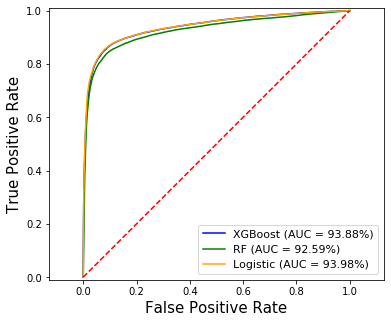

In [155]:
plt.figure(figsize=(6, 5))

plt.plot(fpr_xgb, tpr_xgb, label='XGBoost (AUC = {:,.2f}'.format(roc_auc_xgb*100) + '%' + ')', c='blue')
plt.plot(fpr_rf, tpr_rf, label='RF (AUC = {:,.2f}'.format(roc_auc_rf*100) + '%' + ')', c='green')
#plt.plot(fpr_svm, tpr_svm, label='SVM Linear (AUC = {:,.2f}'.format(roc_auc_svm*100) + '%' + ')', c='fuchsia')
plt.plot(fpr_log, tpr_log, label='Logistic (AUC = {:,.2f}'.format(roc_auc_log*100) + '%' + ')', c='orange')
plt.rc('legend',fontsize=11)
plt.rcParams["axes.labelsize"] = 30

plt.plot([0, 1], [0, 1],'r--')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.ylabel('True Positive Rate', fontsize=15)
plt.xlabel('False Positive Rate', fontsize=15)
plt.axes().set_aspect('equal', 'datalim')
plt.legend(loc="lower right")
#plt.savefig('result_balanced_brasil.pdf')

### Confusion Matrix

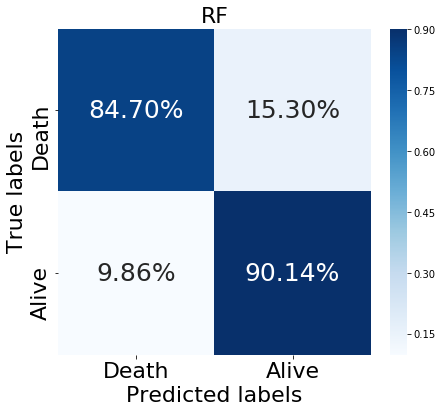

In [11]:
## RANDOM FOREST

cm_rf_perc = np.zeros((2,2))
cm_rf = confusion_matrix(y_test_dummies, y_pred_rf)

plt.figure(figsize = (7,6))

ax=plt.subplot()

cm_rf_perc[0][0] = (cm_rf[1][1]/cm_rf.sum(axis=1)[1])
cm_rf_perc[0][1] = (cm_rf[1][0]/cm_rf.sum(axis=1)[1])
cm_rf_perc[1][0] = (cm_rf[0][1]/cm_rf.sum(axis=1)[0])
cm_rf_perc[1][1] = (cm_rf[0][0]/cm_rf.sum(axis=1)[0])

sns.heatmap(cm_rf_perc, ax = ax, annot=True, annot_kws={"size": 25}, fmt='.2%', cmap="Blues"); #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted labels',fontsize = 22);
ax.set_ylabel('True labels',fontsize = 22); 
ax.set_title('RF', fontsize = 22);
ax.xaxis.set_ticklabels(['Death', 'Alive'], fontsize = 22); 
ax.yaxis.set_ticklabels(['Death', 'Alive'], fontsize = 22);
#plt.savefig('CM_Balan_RF_new.png')

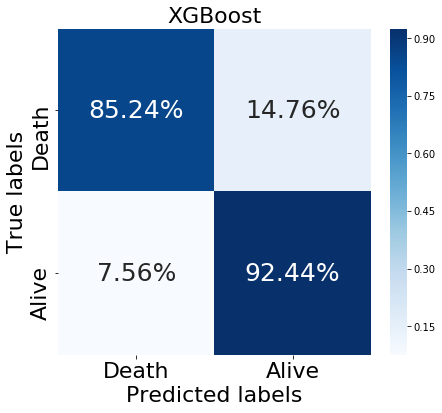

In [12]:
## XGBoost

cm_xgb_perc = np.zeros((2,2))
cm_xgb = confusion_matrix(y_test_dummies, y_pred_xgb)

plt.figure(figsize = (7,6))

ax=plt.subplot()

cm_xgb_perc[0][0] = (cm_xgb[1][1]/cm_xgb.sum(axis=1)[1])
cm_xgb_perc[0][1] = (cm_xgb[1][0]/cm_xgb.sum(axis=1)[1])
cm_xgb_perc[1][0] = (cm_xgb[0][1]/cm_xgb.sum(axis=1)[0])
cm_xgb_perc[1][1] = (cm_xgb[0][0]/cm_xgb.sum(axis=1)[0])

sns.heatmap(cm_xgb_perc, ax = ax, annot=True,annot_kws={"size": 25}, fmt='.2%', cmap="Blues"); #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted labels',fontsize = 22);
ax.set_ylabel('True labels',fontsize = 22); 
ax.set_title('XGBoost', fontsize = 22);
ax.xaxis.set_ticklabels(['Death', 'Alive'], fontsize = 22); 
ax.yaxis.set_ticklabels(['Death', 'Alive'], fontsize = 22);
#plt.savefig('CM_Balan_XGBoost_new.png')

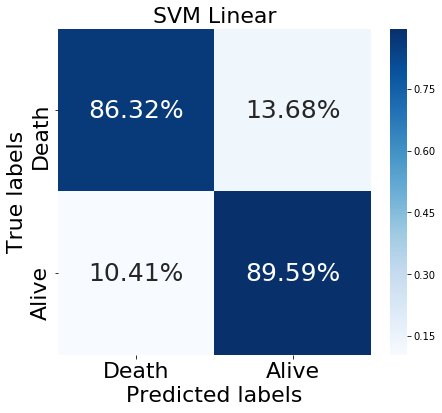

In [13]:
## SVM

cm_svm_perc = np.zeros((2,2))
cm_svm = confusion_matrix(y_test_dummies, y_pred_svm)

plt.figure(figsize = (7,6))

ax=plt.subplot()

cm_svm_perc[0][0] = (cm_svm[1][1]/cm_svm.sum(axis=1)[1])
cm_svm_perc[0][1] = (cm_svm[1][0]/cm_svm.sum(axis=1)[1])
cm_svm_perc[1][0] = (cm_svm[0][1]/cm_svm.sum(axis=1)[0])
cm_svm_perc[1][1] = (cm_svm[0][0]/cm_svm.sum(axis=1)[0])

sns.heatmap(cm_svm_perc, ax = ax, annot=True, annot_kws={"size": 25}, fmt='.2%', cmap="Blues"); #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted labels',fontsize = 22);
ax.set_ylabel('True labels',fontsize = 22); 
ax.set_title('SVM Linear', fontsize = 22);
ax.xaxis.set_ticklabels(['Death', 'Alive'], fontsize = 22); 
ax.yaxis.set_ticklabels(['Death', 'Alive'], fontsize = 22);
#plt.savefig('CM_Balan_SVMLinear_new.png')

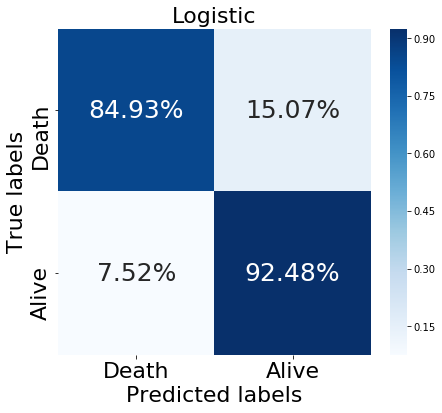

In [14]:
## Logistic

cm_log_perc = np.zeros((2,2))
cm_log = confusion_matrix(y_test_dummies, y_pred_log)

plt.figure(figsize = (7,6))

ax=plt.subplot()

cm_log_perc[0][0] = (cm_log[1][1]/cm_log.sum(axis=1)[1])
cm_log_perc[0][1] = (cm_log[1][0]/cm_log.sum(axis=1)[1])
cm_log_perc[1][0] = (cm_log[0][1]/cm_log.sum(axis=1)[0])
cm_log_perc[1][1] = (cm_log[0][0]/cm_log.sum(axis=1)[0])

sns.heatmap(cm_log_perc, ax = ax, annot=True, annot_kws={"size": 25}, fmt='.2%', cmap="Blues"); #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted labels',fontsize = 22);
ax.set_ylabel('True labels',fontsize = 22); 
ax.set_title('Logistic', fontsize = 22);
ax.xaxis.set_ticklabels(['Death', 'Alive'], fontsize = 22); 
ax.yaxis.set_ticklabels(['Death', 'Alive'], fontsize = 22);
#plt.savefig('CM_Balan_Logistic_new.png')